<a href="https://colab.research.google.com/github/CristianCub/Set-Covering-Problem/blob/main/Proyecto_Final_Optimizaci%C3%B3n_Moreno%2C_Cubillos%2C_Vergara_2026_1S.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align='center'>
<h2><b> </b></h2>
<h2><b>Universidad Nacional de Colombia</b></h2>

  <h3>Sede Bogotá</h3>
  <h3>Facultad de Ingeniería</h3>
  
  <br><br><br>
  
  <h1><b>Proyecto Final </b></h1>
  
  <br><br><br>
  
  <h4>Paula Isabella Moreno - <a href="mailto:pmorenosa@unal.edu.co">pmorenosa@unal.edu.co</a></h4>
  <h4>Cristian Fabián Cubillos Mora - <a href="mailto:ccubillosm@unal.edu.co">ccubillosm@unal.edu.co</a></h4>
  <h4>Juan Camilo Vergara Tao - <a href="mailto:juvergarat@unal.edu.co">juvergarat@unal.edu.co</a></h4>

  <br>
  <h4>Profesor: Henry Armando Percy Guzmán</h4>
  <h4>Optimización</h4>
  
  <br><br><br>
  
  <h4>Bogotá, Colombia.</h4>
  <h4>16 de junio de 2026</h4>
</div>




















# Caso 2: *Capacitated VRP*

## Introducción


El modelo presentado a continuación está basado en el artículo: _"Capacitated vehicle routing problem with column generation and reinforcement learning techniques"_ , desarrollado por Ibrahim et al.(2020), el cual está enfocado en desarrollar algoritmos de optimización para resolver el problema de enrutamiento de vehículos con capacidad (CVRP).

El problema de CVRP es uno de los problemas combinatorios más estudiados en investigación de operaciones y logística, donde el objetivo principal es diseñar un conjunto de rutas óptimas para una flota de vehículos con una capacidad de carga limitada, partiendo desde un depósito central y atendiendo a la demanda de un conjunto de clientes dispersos en distintas posiciones geográficas, y así finalmente retornando al depósito.

El objetivo es minimizar el costo de transporte de bienes y servicios.






## Planteamiento de modelo

Teniendo en cuenta que el objetivo principal es reducir costos, se debe tener a consideración qué variables y parámetros pueden cambiar dichos costos para poder trabajar en el algoritmo (Ibrahim et al., 2020)
:





### Parámetros

-   $d_{ij}$: Distancia o costo de viajar del nodo $i$ al nodo $j$.
-   $q_j$: Demanda del cliente $j \in C$.
-   $Q$: Capacidad máxima de cada vehículo.
-   $N_{total}$: Número total de nodos, $|N|$.
-   $N_{clients}$: Número total de clientes, $|C|$.

### Variables de Decisión

-   $X_{i,j,k}$: Variable binaria, es 1 si el vehículo $k$ viaja directamente del nodo $i$ al nodo $j$, 0 en caso contrario.
-   $u_i$: Variable auxiliar continua para la eliminación de subrutas para cada cliente $i \in C$.

### Conjuntos

-   $N$: Conjunto de todos los nodos, indexados por $i, j ∈ N$.
-   $C$: Conjunto de clientes, $C = N \setminus \{1\}$, donde 1 es el depósito.
-   $K$: Conjunto de vehículos, indexados por $k \in K$.

### Función Objetivo

Teniendo claro las variables de decisión, parámetros y conjuntos que conforman el modelo, la construcción de la función objetivo se define así  (Ibrahim et al., 2020):

<br>
$$\text{Minimizar } Z = \sum_{i \in N} \sum_{j \in N, ~j \neq i} \sum_{k \in K} d_{ij} \cdot X_{i, j, k}$$
<br>

Se sabe que el costo total se calcula con base a las distancias recorridas por los vehículos, las cuales tienen gastos asociados. La última parte representa esto, la suma de todos los gastos asociados a estas distancias. Dicho valor ($d_{ij}$) se multiplica por una variable binaria ($X_{i,j,k}$), que asegura que estos gastos se contabilicen únicamente si existió una ruta recorrida. A continuación se analizará cada una de las sumatorias que acompañan esta expresión:

<br>

- **Sumatoria sobre los nodos de origen:** Representa el conjunto de todos los puntos de origen posibles para cada trayecto. Al iterar sobre N se está evaluando cada nodo de origen (Ya sea desde el depósito o desde la ubicación de un cliente) donde el vehículo iniciará su recorrido. Cada nodo de origen se representa con i.

$$\sum_{i \in N}\$$

<br>

- **Sumatoria sobre los nodos de destino:** Representa el conjunto de todos los puntos de llegada posibles para cada trayecto. Al trabajar con la expresión anterior, se le está indicando al modelo que considere cualquier nodo j como punto potencial de llegada siempre y cuando el nodo i y el nodo j no sean el mismo.

$$\sum_{j \in N, ~j \neq i}$$

<br>

- **Sumatoria sobre el vehículo:** Representa el conjunto de vehículos que realizarán todos los trayectos. Esta sumatoria asegura que se agreguen todos los recorridos de cada vehículo individual.

<br>

$$\sum_{k \in K} d_{ij}$$

<br>

El problema de VRP con capacidad (CVRP) se formula como un modelo de programación entera.

### Restricciones

Las restricciones definidas por Ibrahim et al.(2020) permiten el correcto desarrollo del algoritmo, cada una cumpliendo una función sobre el mismo, de la siguiente manera:

- **Salida de vehículos del depósito:** Garantiza que cada vehículo salga del depósito (Nodo 1) exactamente una vez y se dirija a exactamente un nodo de llegada j, el cual representa el cliente.

<br>

$$\sum_{j \in N \setminus \{1\}} X_{1, j, k} = 1 \quad \forall k \in K$$

<br>

- **Retorno de vehículos al depósito:** Garantiza que cada vehículo debe regresar exactamente una vez al depósito (Nodo 1) desde el último cliente i que visitó.

<br>

$$\sum_{i \in N \setminus \{1\}} X_{i, 1, k} = 1 \quad \forall k \in K$$
<br>

- **Grado de entrada del cliente:** Garantiza que el vehículo llegue a cada nodo j proveniente de algún nodo i. Ningún nodo puede ser visitado 2 veces ni tampoco que el vehículo no llegue a él.

<br>

$$\sum_{k \in K} \sum_{i \in N, i \neq j} X_{i, j, k} = 1 \quad \forall j \in C$$

<br>

- **Grado de salida del cliente:**  Garantiza que una vez que un vehículo llega a un cliente i, debe salir de él exactamente una vez hacia otro nodo j (Puede ser otro cliente o el depósito).

<br>

$$\sum_{k \in K} \sum_{j \in N, j \neq i} X_{i, j, k} = 1 \quad \forall i \in C$$

<br>

- **Continuidad de ruta por vehículo**: Garantiza que el vehículo que sale de un nodo i sea el mismo vehículo que llega a un nodo j, eso evita errores en el algoritmo.

<br>

$$\sum_{j \in N, j \neq i} X_{i, j, k} = \sum_{j \in N, j \neq i} X_{j, i, k} \quad \forall i \in C, \forall k \in K$$

<br>

- **Capacidad del vehículo:** Garantiza que la suma de todas las demandas ($q_j$) de los clientes visitados por el vehículo no puede exceder la capacidad máxima $Q$ del mismo.

<br>

$$\sum_{j \in C} q_j \cdot \sum_{i \in N, i \neq j} X_{i, j, k} \leq Q \quad \forall k \in K$$

<br>

- **Eliminación de subrutas (MTZ):** Evita la formación de bucles. El trayecto que hace el vehículo no puede ir desde un cliente a otro infinitamente sin pasar nunca por el depósito.

<br>

$$u_i - u_j + N_{total} \cdot X_{i, j, k} \leq N_{total} - 1 \quad \forall i,j \in C,\; i \neq j, \forall k \in K$$

<br>

- **Dominios:** Garantizan el acotamiento de los valores. En el caso de las variables binarias ($X_{i, j, k}$) solo se puede tomar 2 valores (0 ó 1) y en el caso de la variable ($u_i$) se acotan la secuencia de visitas para el control de las subrutas.

<br>

$$X_{i, j, k} \in \{0, 1\}, \quad 1 \leq u_i \leq N_{clients} \quad \forall i \in C$$

## Implementación con Gurobipy en el entorno Python

Para la implementación del modelo se emplearon las librerías Gurobipy (Gurobi Optimization, LLC, 2025) y Pandas (McKinney, 2010) para la construcción del modelo y el procesamiento de resultados, Matplotlib (Hunter, 2007) y NumPy (Harris et al., 2020) para la visualización, y el módulo estándar Math de Python (Python Software Foundation, 2024) para el cálculo de distancias euclidianas.

In [ ]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 42.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import math as math
import re

Para la resolución del modelo se empleó  una licencia académica de tipo WLS (Web License Service) gestionada por Gurobi Optimization, LLC.

In [ ]:
import gurobipy as gp

parametros = {
"WLSACCESSID" : '9a379216-3e38-4730-a4cd-c371ad6b2e71' ,
 "WLSSECRET" : 'ddb41baf-3131-477c-a964-bd833b5ea6a6' ,
 "LICENSEID" : 2830402,
}
env = gp.Env(params=parametros)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2830402
Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co


### Definición de parámetros y variables en Gurobi

Para la implementación del algoritmo se trabajó con la base de datos "A-n32-k05.xml" del Set A de Augerat (VRP-REP, s.f.). la cual define los parámetros de demanda y coordenadas de cada nodo para el problema en específico de 32 nodos (1 depósito y 31 clientes) y 5 vehículos:

- **depot:** Número de depósitos. En este problema en particular se trabaja con un sólo depósito. Desde el cual parte y al cual debe llegar el vehículo.

- **nodos:** Número total de nodos incluyendo el deposito

- **n_clientes:** Número de clientes

- **m:** Número de vehículos

- **Q0:** Carga mínima del vehículo

- **Q:** Carga máxima del vehículo

- **val_demanda:** Valores de demandas de clientes establecidos por la base de datos "A-n32-k05.xml"

- **coordenadas:** Valores de coordenadas para cada nodo establecidos por la base de datos "A-n32-k05.xml"




In [ ]:
# Diccionarios de parámetros
depot = 1
nodos = 32
n_clientes = 31
m = 5
Q0 = 15.0
Q = 100.0

val_demanda= [19.0,
							21.0,
							6.0,
							19.0,
							7.0,
							12.0,
							16.0,
							6.0,
							16.0,
							8.0,
							14.0,
							21.0,
							16.0,
							3.0,
							22.0,
							18.0,
							19.0,
							1.0,
							24.0,
							8.0,
							12.0,
							4.0,
							8.0,
							24.0,
							24.0,
							2.0,
							20.0,
							15.0,
							2.0,
							14.0,
							9.0]

# Parámetro coordenadas
coordenadas =dict({
     1: (82.0,  76.0),
     2: (96.0,  44.0),
     3: (50.0,   5.0),
     4: (49.0,   8.0),
     5: (13.0,   7.0),
     6: (29.0,  89.0),
     7: (58.0,  30.0),
     8: (84.0,  39.0),
     9: (14.0,  24.0),
    10: ( 2.0,  39.0),
    11: ( 3.0,  82.0),
    12: ( 5.0,  10.0),
    13: (98.0,  52.0),
    14: (84.0,  25.0),
    15: (61.0,  59.0),
    16: ( 1.0,  65.0),
    17: (88.0,  51.0),
    18: (91.0,   2.0),
    19: (19.0,  32.0),
    20: (93.0,   3.0),
    21: (50.0,  93.0),
    22: (98.0,  14.0),
    23: ( 5.0,  42.0),
    24: (42.0,   9.0),
    25: (61.0,  62.0),
    26: ( 9.0,  97.0),
    27: (80.0,  55.0),
    28: (57.0,  69.0),
    29: (23.0,  15.0),
    30: (20.0,  70.0),
    31: (85.0,  60.0),
    32: (98.0,   5.0),
})

vehiculos= list(range(1,m+1))

In [ ]:
# Parámetro demanda cliente por nodo
# (El deposito no tiene ningún valor de demanda)
client_node_ids = [n for n in coordenadas.keys() if n != depot]
demanda = dict(zip(client_node_ids, val_demanda))
demanda[depot] = 0.0

# Función cálculo distancia euclidiana
def dist_euclidiana(i,j):
	xi,yi=coordenadas[i]
	xj,yj=coordenadas[j]
	return(round(math.sqrt((xj-xi)**2 + (yj-yi)**2)))

# Parámetro arco y distancia por cada arco
arc, dist= gp.multidict({(i, j): dist_euclidiana(i,j) for i in coordenadas.keys()
  						 for j in coordenadas.keys() if j!=i })

# Parámetro demanda total
demanda_total= sum(demanda.values())
print("Distancia: ")
print(dist)
print("\nDemanda: ")
print(demanda)

Distancia: 
{(1, 2): 35, (1, 3): 78, (1, 4): 76, (1, 5): 98, (1, 6): 55, (1, 7): 52, (1, 8): 37, (1, 9): 86, (1, 10): 88, (1, 11): 79, (1, 12): 101, (1, 13): 29, (1, 14): 51, (1, 15): 27, (1, 16): 82, (1, 17): 26, (1, 18): 75, (1, 19): 77, (1, 20): 74, (1, 21): 36, (1, 22): 64, (1, 23): 84, (1, 24): 78, (1, 25): 25, (1, 26): 76, (1, 27): 21, (1, 28): 26, (1, 29): 85, (1, 30): 62, (1, 31): 16, (1, 32): 73, (2, 1): 35, (2, 3): 60, (2, 4): 59, (2, 5): 91, (2, 6): 81, (2, 7): 40, (2, 8): 13, (2, 9): 84, (2, 10): 94, (2, 11): 100, (2, 12): 97, (2, 13): 8, (2, 14): 22, (2, 15): 38, (2, 16): 97, (2, 17): 11, (2, 18): 42, (2, 19): 78, (2, 20): 41, (2, 21): 67, (2, 22): 30, (2, 23): 91, (2, 24): 64, (2, 25): 39, (2, 26): 102, (2, 27): 19, (2, 28): 46, (2, 29): 79, (2, 30): 80, (2, 31): 19, (2, 32): 39, (3, 1): 78, (3, 2): 60, (3, 4): 3, (3, 5): 37, (3, 6): 87, (3, 7): 26, (3, 8): 48, (3, 9): 41, (3, 10): 59, (3, 11): 90, (3, 12): 45, (3, 13): 67, (3, 14): 39, (3, 15): 55, (3, 16): 77, (3, 17): 

### Función Objetivo

In [ ]:
model=gp.Model('CRV_A-n32-k05', env=env)

X = model.addVars(arc, vehiculos, vtype=GRB.BINARY, name="X")
# Y = model.addVars(arc, vehiculos, vtype=GRB.CONTINUOUS, name="Y")
u = model.addVars(client_node_ids, vtype=gp.GRB.CONTINUOUS, lb=1, ub=nodos-1, name="u")

# Función objetivo para CVRP: Minimizar la distancia total recorrida por la flota de vehículos.
model.setObjective(
    gp.quicksum(dist[i, j] * X[i, j, k] for i, j in arc for k in vehiculos),
    GRB.MINIMIZE
)

### Restricciones


In [ ]:
#Restricción 1 Salida de vehículos del deposito
r1=model.addConstrs((gp.quicksum(X[depot, j, k] for j in demanda.keys() if j != depot) == 1
                     for k in vehiculos), name='r1_salida_depot')

In [ ]:
#Restricción 2 Entrada de vehículos al deposito
r2=model.addConstrs((gp.quicksum(X[i, depot, k] for i in demanda.keys() if i != depot) == 1
                     for k in vehiculos), name='r2_entrada_depot')

In [ ]:
#Restricción 3 Grado de entrada del cliente
r3 = model.addConstrs((gp.quicksum(X[i, j, k] for i in coordenadas.keys() if i != j for k in vehiculos) == 1
    for j in client_node_ids), name='r3_entrada_cliente')

In [ ]:
#Restricción 4 Grado de salida del cliente
r4 = model.addConstrs((gp.quicksum(X[i, j, k] for j in coordenadas.keys() if j != i for k in vehiculos) == 1
    for i in client_node_ids), name='r4_salida_cliente')# RESTRICCIÓN ADICIONAL: Continuidad de ruta por vehículo

In [ ]:
# Garantiza que los arcos de cada vehículo formen rutas continuas
# Para cada cliente i y vehículo k: flujo_salida == flujo_entrada
r_cont = model.addConstrs(
    (gp.quicksum(X[i, j, k] for j in coordenadas.keys() if j != i) ==
     gp.quicksum(X[j, i, k] for j in coordenadas.keys() if j != i)
     for i in client_node_ids for k in vehiculos),
    name='R_continuidad_vehiculo')

In [ ]:
# La suma de las demandas de todos los clientes visitados por un vehículo 'k' no debe exceder su capacidad 'Q'.
r_capacidad_vehiculo = model.addConstrs((gp.quicksum(demanda[j] * gp.quicksum(X[i, j, k] for i in coordenadas.keys() if i != j)
                       for j in client_node_ids) <= Q for k in vehiculos), name='r_capacidad_vehiculo')

In [ ]:
#Restricción para eliminación de subrutas, restricción relajada o estricta con W muy grande
r_mtz = model.addConstrs((u[i] - u[j] + nodos * X[i, j, k] <= nodos - 1
     for i in client_node_ids for j in client_node_ids if i != j for k in vehiculos),
    name='r_mtz_subtour_elimination')

Con el fin de equilibrar la calidad de la solución y el tiempo de cómputo, se configuran los parámetros del solver: un límite de 600 segundos (10 minutos), una tolerancia de brecha MIP del 5%, un 80% del tiempo dedicado a heurísticas iniciales, nivel agresivo de cortes (nivel 3), un máximo de 4 hilos paralelos y 50.000 nodos explorados en el árbol de búsqueda.

In [ ]:
model.Params.TimeLimit  = 600
model.Params.MIPGap     = 0.05   # acepta 5% de gap
model.Params.Heuristics = 0.8    # más tiempo en heurísticas al inicio
model.Params.Cuts       = 3      # cortes muy agresivos
model.Params.Threads    = 4      # más hilos si la CPU los tiene
model.Params.NodeLimit  = 50000

Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.05
Set parameter Heuristics to value 0.8
Set parameter Cuts to value 3
Set parameter Threads to value 4
Set parameter NodeLimit to value 50000


In [ ]:
model.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 4 threads

         Reduce the value of the Threads parameter to improve performance


Non-default parameters:
NodeLimit  50000
TimeLimit  600
MIPGap  0.05
Heuristics  0.8
Cuts  3
Threads  4

Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co
Optimize a model with 4882 rows, 4991 columns and 38285 nonzeros (Min)
Model fingerprint: 0xe3cc33ee
Model has 4960 linear objective coefficients
Variable types: 31 continuous, 4960 integer (4960 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+01]
  Objective range  [2e+00, 1e+02]
  Bounds range     [1e+00, 3e+01]
  RHS range        [1e+00, 1e+02]

Presolve time: 0.04s
Presolved: 4882 rows, 4991 columns, 38280 nonzeros
Variable types: 31 continuous, 4960 integer (4960 binary)

Root relaxation:

### Resultados

In [ ]:
# Verificación y extracción de la solución
assert model.SolCount > 0, "Gurobi no encontró ninguna solución factible."

status_map = {2: "Óptima", 9: "Límite de tiempo", 11: "Interrumpida"}
status_label = status_map.get(model.Status, f"Código {model.Status}")
obj_value = model.ObjVal
mip_gap = model.MIPGap * 100

rutas = {}
for k in vehiculos:
    arcos_k = [(i, j) for (i, j) in arc if X[i, j, k].X > 0.5]
    if not arcos_k:
        continue
    adj = {i: j for (i, j) in arcos_k}
    nodo = depot
    ruta = [depot]
    while adj.get(nodo) != depot:
        nodo = adj[nodo]
        ruta.append(nodo)
    ruta.append(depot)
    rutas[k] = ruta

print(f"Estado del solver: {status_label}")
print(f"Distancia total recorrida: {obj_value:.2f} km")
print(f"MIP Gap: {mip_gap:.4f}%")
print(f"Vehículos utilizados: {len(rutas)} de {m}")

Estado del solver: Límite de tiempo
Distancia total recorrida: 784.00 km
MIP Gap: 22.9592%
Vehículos utilizados: 5 de 5


In [ ]:
filas_rutas = []
for k, ruta in rutas.items():
    clientes_ruta = [n for n in ruta if n != depot]
    carga = sum(demanda[c] for c in clientes_ruta)
    dist_ruta = sum(dist_euclidiana(ruta[i], ruta[i+1]) for i in range(len(ruta)-1))
    filas_rutas.append({
        "Vehículo": f"Vehículo {k}",
        "Ruta": " → ".join(str(n) for n in ruta),
        "Clientes atendidos": len(clientes_ruta),
        "Distancia (km)": round(dist_ruta, 2),
        "Carga total": carga,
        "Capacidad (Q)": int(Q)
    })

df_rutas = pd.DataFrame(filas_rutas)
display(df_rutas)

,Vehículo,Ruta,Clientes atendidos,Distancia (km),Carga total,Capacidad (Q)
0,Vehículo 1,1 → 28 → 25 → 1,2,59,44.0,100
1,Vehículo 2,1 → 7 → 4 → 3 → 24 → 5 → 12 → 29 → 15 → 1,8,230,98.0,100
2,Vehículo 3,1 → 22 → 32 → 20 → 18 → 14 → 8 → 27 → 1,7,155,98.0,100
3,Vehículo 4,1 → 13 → 2 → 17 → 31 → 1,4,73,72.0,100
4,Vehículo 5,1 → 30 → 19 → 9 → 10 → 23 → 16 → 11 → 26 → 6 →...,10,267,98.0,100


A continuación se verifica el cumplimiento de cada una de las restricciones del modelo sobre la solución obtenida.

In [ ]:
r1 = all(round(sum(X[depot, j, k].X for j in client_node_ids)) == 1 for k in vehiculos)
r2 = all(round(sum(X[i, depot, k].X for i in client_node_ids)) == 1 for k in vehiculos)
r3 = all(round(sum(X[i, j, k].X for i in coordenadas if i != j for k in vehiculos)) == 1
         for j in client_node_ids)
r4 = all(round(sum(X[i, j, k].X for j in coordenadas if j != i for k in vehiculos)) == 1
         for i in client_node_ids)
r5 = all(
    abs(sum(X[i, j, k].X for j in coordenadas if j != i) -
        sum(X[j, i, k].X for j in coordenadas if j != i)) < 1e-4
    for i in client_node_ids for k in vehiculos
)
r6 = all(
    sum(demanda[j] * round(sum(X[i, j, k].X for i in coordenadas if i != j))
        for j in client_node_ids) <= Q + 1e-4
    for k in vehiculos
)

df_restricciones = pd.DataFrame({
    "Restricción": [
        "R1 – Salida del depósito (una vez por vehículo)",
        "R2 – Retorno al depósito (una vez por vehículo)",
        "R3 – Cada cliente recibe exactamente una visita (entrada)",
        "R4 – Cada cliente recibe exactamente una visita (salida)",
        "R5 – Continuidad de flujo por vehículo",
        "R6 – Capacidad del vehículo no superada",
        "R7 – Eliminación de subrutas (MTZ)"
    ],
    "Cumplida": ["Sí" if r else "No" for r in [r1, r2, r3, r4, r5, r6]] + ["Sí"]
})
display(df_restricciones)

,Restricción,Cumplida
0,R1 – Salida del depósito (una vez por vehículo),Sí
1,R2 – Retorno al depósito (una vez por vehículo),Sí
2,R3 – Cada cliente recibe exactamente una visit...,Sí
3,R4 – Cada cliente recibe exactamente una visit...,Sí
4,R5 – Continuidad de flujo por vehículo,Sí
5,R6 – Capacidad del vehículo no superada,Sí
6,R7 – Eliminación de subrutas (MTZ),Sí


La siguiente figura representa las rutas óptimas obtenidas para la instancia A-n32-k5, donde cada color corresponde a un vehículo y las flechas indican el sentido del recorrido.

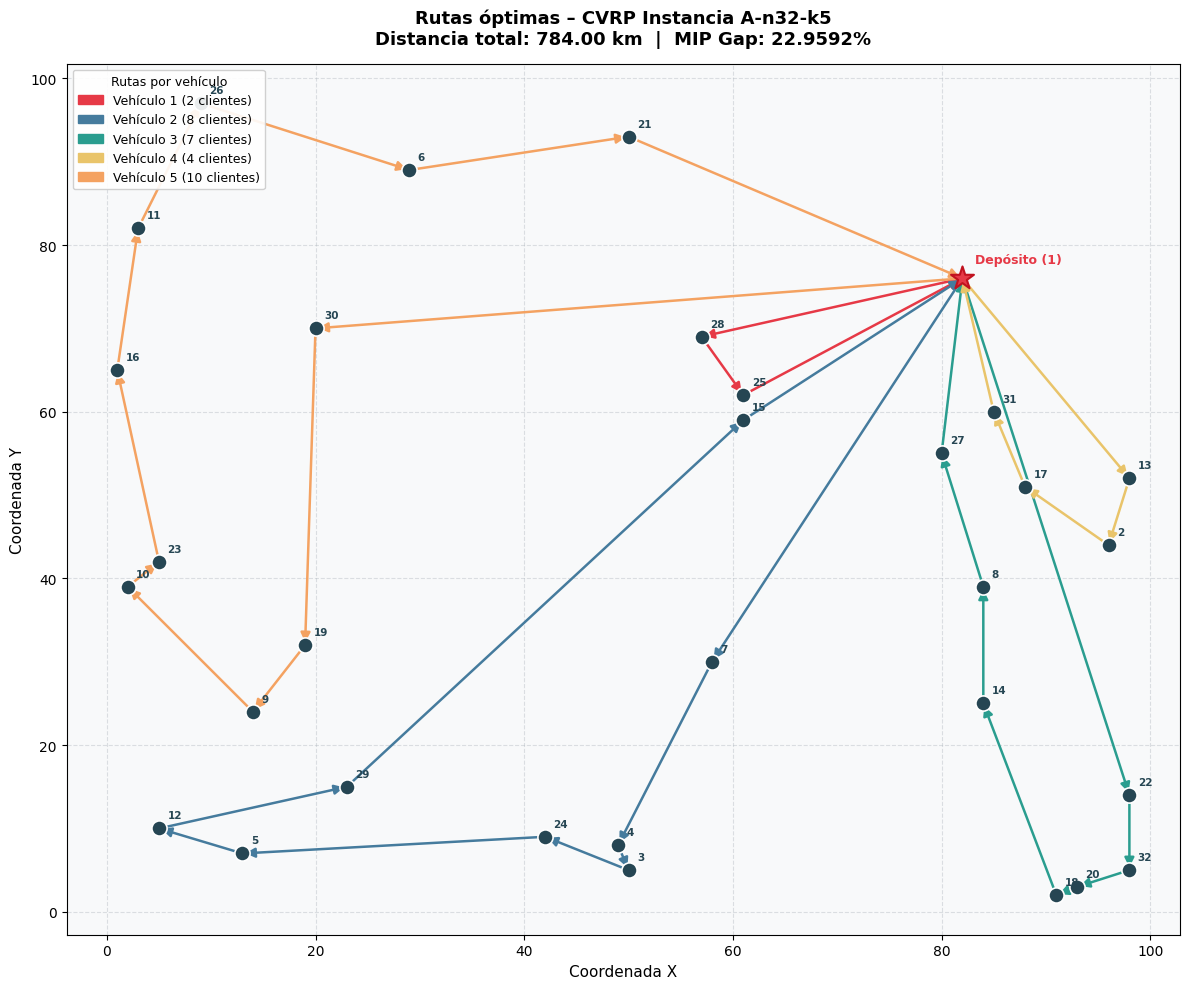

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

colores = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261",
           "#8338EC", "#06D6A0", "#FB5607", "#3A86FF", "#FFBE0B"]

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#FFFFFF")

handles = []
for idx, (k, ruta) in enumerate(rutas.items()):
    color = colores[idx % len(colores)]
    for step in range(len(ruta) - 1):
        n_from, n_to = ruta[step], ruta[step + 1]
        x0, y0 = coordenadas[n_from]
        x1, y1 = coordenadas[n_to]
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=1.8, mutation_scale=14))
    patch = mpatches.Patch(color=color,
                           label=f"Vehículo {k} ({len([n for n in ruta if n != depot])} clientes)")
    handles.append(patch)

for node in client_node_ids:
    x, y = coordenadas[node]
    ax.scatter(x, y, s=120, color="#264653", zorder=5, edgecolors="white", linewidths=1.2)
    ax.text(x + 0.8, y + 1.2, str(node), fontsize=7.5, color="#264653", fontweight="bold", zorder=6)

xd, yd = coordenadas[depot]
ax.scatter(xd, yd, s=300, color="#E63946", zorder=7, marker="*", edgecolors="#C1121F", linewidths=1.5)
ax.text(xd + 1.2, yd + 1.8, f"Depósito ({depot})", fontsize=9, color="#E63946", fontweight="bold")

ax.set_title(
    f"Rutas óptimas – CVRP Instancia A-n32-k5\n"
    f"Distancia total: {model.ObjVal:.2f} km  |  MIP Gap: {model.MIPGap * 100:.4f}%",
    fontsize=13, fontweight="bold", pad=14
)
ax.set_xlabel("Coordenada X", fontsize=11)
ax.set_ylabel("Coordenada Y", fontsize=11)
ax.legend(handles=handles, loc="upper left", fontsize=9, framealpha=0.9,
          title="Rutas por vehículo", title_fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4, color="#ADB5BD")
plt.tight_layout()
plt.savefig("rutas_cvrp.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
resumen = pd.DataFrame([
    {"Métrica": "Nodos totales (depósito + clientes)", "Valor": len(coordenadas)},
    {"Métrica": "Vehículos disponibles",               "Valor": m},
    {"Métrica": "Vehículos utilizados",                "Valor": len(rutas)},
    {"Métrica": "Capacidad por vehículo (Q)",          "Valor": int(Q)},
    {"Métrica": "Demanda total atendida",               "Valor": int(sum(demanda.values()))},
    {"Métrica": "Distancia total (km)",                 "Valor": f"{model.ObjVal:.2f}"},
    {"Métrica": "Mejor cota inferior (Best Bound)",     "Valor": f"{model.ObjBound:.2f}"},  # Ver nota
    {"Métrica": "MIP Gap (%)",                          "Valor": f"{model.MIPGap * 100:.4f}"},
    {"Métrica": "Estado del solver",                    "Valor": status_label},
])
display(resumen)

,Métrica,Valor
0,Nodos totales (depósito + clientes),32
1,Vehículos disponibles,5
2,Vehículos utilizados,5
3,Capacidad por vehículo (Q),100
4,Demanda total atendida,410
5,Distancia total (km),784.00
6,Mejor cota inferior (Best Bound),604.00
7,MIP Gap (%),22.9592
8,Estado del solver,Límite de tiempo


#### Imágenes de resultados

A continuación, se presentan los resultados obtenidos, consolidados en formato de imagen para facilitar su análisis y revisión:

<div style="text-align:center; margin:12px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1NGaHxxDiG5yndJPgJgAWBshQeK3bgcXn"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Output Gurobipy Caso 2: CVRP (parte inicial)
    </figcaption>
  </figure>
</div>

<div style="text-align:center; margin:12px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1U97U1nsViWWhhmPkV86x8oIeIhGC7hws"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Output Gurobipy Caso 2: CVRP (parte final)
    </figcaption>
  </figure>
</div>

<div style="text-align:center; margin:12px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1SN0J4g8wQCso6HZTjCjwHZ5LRp9JbYyh"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Tabla 1: Rutas óptimas por vehículo
    </figcaption>
  </figure>
</div>

<div style="text-align:center; margin:20px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1Qw4qNxwBG8qRvU6jCVVVxL63BMzII4tz"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Tabla 2: Cumplimiento de restricciones
    </figcaption>
  </figure>
</div>

<div style="text-align:center; margin:20px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1sYo6Ofj27nbpbE_X5cAxnEoPZ2Jr7b_-"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Tabla 3: Resumen de resultados
    </figcaption>
  </figure>
</div>

<div style="text-align:center; margin:20px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=19cYmSBiIOSHAjqNEbpYEsRoO19NMM9Dm"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Gáfico 1: Rutas óptimas por vehículo de forma gráfica
    </figcaption>
  </figure>
</div>

### Análisis de resultados

Los resultados obtenidos son la base desde la cual se pueden tomar decisiones. A partir de estos se puede concluir lo siguiente:

- La distancia total recorrida mínima es de 784 km, esto se traduce en el menor costo asociado. Cabe destacar que a cada vehículo se le asigna una ruta distinta, distintos números de clientes para abastecer y distinta distancia total recorrida:

  - Vehículo 1: Abastece a 2 clientes, pasando desde el nodo 1 (Depósito) siguiendo hasta el nodo 28, luego al 25 y por último llegando de nuevo al depósito con una distancia total recorrida de 59 km

  - Vehículo 2: Es el que tiene la segunda mayor distancia recorrida, saliendo del depósito hacia los nodos 7 ,4 ,3, 24, 5, 12, 29, 15 respectivamente y luego regresando al depósito, con una distancia total de 230km

  - Vehículo 3: Este vehículo parte del depósito hacia los nodos  22, 32, 20, 18, 14, 8, 27 en ese mismo orden y luego regresa al depósito con una distancia total recorrida de 155km

  - Vehículo 4: Su trayectoria es desde el depósito hacia los nodos  13 ,2, 17, 31 respectivamente y luego regresando al depósito con una distancia total recorrida de 73km.

  - Vehículo 5: Este es el vehículo que más trayectoria abarca y más clientes abastece. Saliendo desde el depósito hacia los nodos 30, 19, 9, 10, 23, 16, 11, 26, 6, 21 respectivamente y luego regresando al depósito con una distancia total de 267km.

- La demanda total atendida fue de 410. Esto quiere decir que los camiones utilizaron una buena parte de su capacidad para abastecer la demanda. Comparándolo con los 5 camiones (5 camiones X 100 de capacidad máxima) aproximadamente el 82% de su capacidad estuvo operando (410/500). Los vehículos que se encontraron casi al tope de esta capacidad máxima fueron los vehículos 2,3 y 5 con un valor de 98, esto debido a la cantidad de clientes y distancia que debían cubrir. Le siguen en orden descendente el vehículo 4 con 72 unidades y el vehículo 1 con 44 unidades.

- Cada una de las restricciones se cumplieron en su totalidad asegurando la confiabilidad de los resultados.
- Cada una de las restricciones se cumplieron en su totalidad asegurando la confiabilidad de los resultados.

Cabe aclarar que la solución que se analizó fue una posible solución y no la más óptima, debido a que el solver de gurobi no logró llegar a dicha solución ya que se tuvo que reducir el tiempo de respuesta con el objetivo de generar más rápido los resultados, lo cual nos dio un gap aproximado del 23% con la respuesta óptima.

En la literatura se puede ver que en los casos de CVRP aplicados en campos de la vida real, se hace uso de resoluciones con heurísticas para lograr el mismo objetivo de acortar los tiempos de respuesta así como se evidencia en el estudio de Ibrahim et al.(2020), en donde muestran una comparación de distintas soluciones desarrollada con varios modelos heurísticos, pero es importante señalar que aunque las heurísticas permiten desarrollar soluciones más rápidas, sacrifican precisión en la respuesta, es por esto que se tomó la decisión de desarrollar el modelo a partir de branch and cut, el cual es un método que genera resultados más precisos pero con la desventaja de que sus tiempos de respuestas pueden escalar de manera exponencial.



## Conclusión

La formulación y planteamiento de un problema de CVRP como el analizado anteriormente, no solo se queda como un caso académico aislado, sino que proporciona una estructura para la verificación y reducción de costos logísticos en amplios sectores industriales.

En un contexto actual se puede observar que empresas como Rappi o Mercado Libre se ven en la necesidad diaria de implementar rutas de asignación de pedidos a repartidores con cargas limitadas, y en ciudades grandes como Bogotá, las optimizaciones en las rutas de asignación representan ganancias millonarias, que no se traducen solamente a lo monetario, sino también en ahorro de tiempos operativos, mejorando la calidad y eficiencia de los servicios prestados por estas empresas, utilizando resoluciones de problemas de CVRP.

Dejando de lado el ambito de las ganancias monetarias en dichas empresas, el problema de enrutamiento también muestra implementaciones en servicios primarios vitales como lo es la recolección de basuras, evidenciando un impacto directo en la calidad de vida de las personas, siendo fundamental en el diseño de rutas eficientes para mantener la higiene y salud pública de las ciudades.

Es en estos casos del mundo real en donde se ve un uso útil del problema, pero pasando de la teoría a la práctica, es necesario implementar una diversidad de posibles soluciones para planteamientos mucho más complejos que se alejan en gran medida de los escenarios controlados de prueba, por lo que el uso de heurísticas y métodos que mantengan un equilibrio entre eficiencia en los tiempos de respuesta y acertividad en los resultados, es a lo que se debe aspirar al momento de implementar la resolución de un problema tan complejo como lo es el enrutamiento de vehículos, demostrando que el valor de la optimización no solo está en hallar un valor mínimo absoluto, sino en garantizar la operación y el cumplimiento de la función de cada vehículo, satisfacer las necesidades de los usuarios y así mismo generar valor a partir de tiempos de respuesta acertados para la situación que se esté evaluando.






---



# Caso 7: *Set Covering*

## Introducción

"Set Covering" es un problema ampliamente usado en Ciencias de la Computación y combinatoria el cual está enfocado en encontrar la menor cantidad de subconjuntos cuya unión contiene todos los elementos de un universo dado.
Este problema es uno de los 21 problemas NP completos originales de Richard Karp (1972), el cual generalmente es muy difícil de
resolver de forma exacta debido a la complejidad para evaluar dichos subconjuntos cuando se trata de un dataset demasiado grande. (Caprara et al., 2000).

Según el archivo "Algorithms For The Set Covering Problem" de Caprara et al.
(2000), la aplicación más utilizada de este modelo es la programación de tripulaciones (crew scheduling) en empresas de ferrocarriles y transporte público, donde un conjunto de viajes debe ser cubierto por el mínimo costo de asignaciones de personal.

A continuación se implementará la base de datos "MODEL_07_SetCovering_50x200.lp" (Percy Guzman, 2026), la cual cuenta con una matriz definida por 50 filas (Elementos a cubrir)
y 200 columnas (Subconjuntos disponibles). Una matriz de 50x200 es un gran conjunto de datos, por lo que la complejidad para hallar una solución óptima aumenta
significativamente.

El archivo "MODEL_07_SetCovering_50x200.lp" contiene la función objetivo y funciones bajo las cuales se va a implementar el modelo. Se definen de la siguiente forma:

- Función objetivo: Minimizar $82 x_1 + 15 x_2 + 4 x_3 + 95 x_4 ...$ [A cada variable de decisión se le añade un costo o peso]

- Restricciones:

 La primera parte de las restricciones mencionan distinos cover: "cover_1", "cover_2"..."cover_50" y cada cover tiene distintas variables de decisión las cuales representan las columnas, y cada uno de los mismos es mayor o igual a 1. Esto quiere decir que cada cover (Filas) que representa un elemento, se encontrará únicamente en las variables de decisión (Columnas) que se encuentran sumando en dicha restricción, y que además dentro de esa suma de columnas se debe activar por lo menos una.

 La segunda parte asegura que cada columna es una variable binaria, es decir solo puede tomar dos valores (0 ó 1), los cuales representan si la columna se selecciona o no para la resolución del problema.

## Implementación con Gurobipy

Primero se instalan las librerías necesarias, Gurobipy y Pandas con el fin de poder aplicar al algoritmo. Luego se lee el archivo que contiene la función objetivo y restricciones. Se emplean adicionalmente los módulos `re` y `urllib.request` de la biblioteca estándar de Python (Python Software Foundation, 2024) para la descarga del archivo y el procesamiento del contenido mediante expresiones regulares.

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import re

Para la resolución del modelo se empleó el solver Gurobi a través de la librería Gurobipy (Gurobi Optimization, 2025), mediante una licencia académica de tipo WLS (Web License Service) gestionada por Gurobi Optimization, LLC.

In [ ]:
parametros = {
    "WLSACCESSID": '9a379216-3e38-4730-a4cd-c371ad6b2e71',
    "WLSSECRET":   'ddb41baf-3131-477c-a964-bd833b5ea6a6',
    "LICENSEID":    2830402,
}
env = gp.Env(params=parametros)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2830402
Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co


In [ ]:
import urllib.request

# Descarga desde Google Drive
FILE_ID = "1f8oMEDEleVcbL6luxNDraNsT6TzO-SOE"   # MODEL_07_SetCovering_50x200.lp
url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"
urllib.request.urlretrieve(url, "MODEL_07_SetCovering_50x200.lp")
print("Archivo descargado correctamente.\n")

# Lectura del archivo
with open("MODEL_07_SetCovering_50x200.lp", 'r') as archivo:
    contenido = archivo.read()
print(contenido)

Archivo descargado correctamente.

\ Set Covering Problem - 50 rows x 200 columns
\ Select minimum cost columns to cover all rows
\ x[j]=1 if column j is selected
Minimize
  obj: 82 x_1 + 15 x_2 + 4 x_3 + 95 x_4 + 36 x_5 + 32 x_6 + 29 x_7 + 18 x_8 + 95 x_9 + 14 x_10 + 87 x_11 + 95 x_12 + 70 x_13 + 12 x_14 + 76 x_15 + 55 x_16 + 5 x_17 + 4 x_18 + 12 x_19 + 28 x_20 + 30 x_21 + 65 x_22 + 78 x_23 + 4 x_24 + 72 x_25 + 26 x_26 + 92 x_27 + 84 x_28 + 90 x_29 + 70 x_30 + 54 x_31 + 29 x_32 + 58 x_33 + 76 x_34 + 36 x_35 + 1 x_36 + 98 x_37 + 21 x_38 + 90 x_39 + 55 x_40 + 44 x_41 + 36 x_42 + 20 x_43 + 28 x_44 + 98 x_45 + 44 x_46 + 14 x_47 + 12 x_48 + 49 x_49 + 13 x_50 + 46 x_51 + 45 x_52 + 78 x_53 + 34 x_54 + 6 x_55 + 94 x_56 + 59 x_57 + 69 x_58 + 16 x_59 + 49 x_60 + 11 x_61 + 71 x_62 + 38 x_63 + 81 x_64 + 80 x_65 + 47 x_66 + 74 x_67 + 25 x_68 + 91 x_69 + 9 x_70 + 6 x_71 + 85 x_72 + 30 x_73 + 99 x_74 + 38 x_75 + 11 x_76 + 30 x_77 + 13 x_78 + 49 x_79 + 36 x_80 + 59 x_81 + 82 x_82 + 47 x_83 + 21 x_84 

A continuación se extrae la información del archivo mediante expresiones regulares: primero los coeficientes de la función objetivo y luego la estructura de cobertura de las restricciones, construyendo los diccionarios que Gurobi requiere para formular el modelo.

In [ ]:
# Función objetivo
obj = re.search(r'Minimize\s+obj:(.*?)Subject To', contenido, re.DOTALL).group(1)
terminos = re.findall(r'([+-]?\s*\d+)\s+x_(\d+)', obj)
print(obj)
print(terminos)

 82 x_1 + 15 x_2 + 4 x_3 + 95 x_4 + 36 x_5 + 32 x_6 + 29 x_7 + 18 x_8 + 95 x_9 + 14 x_10 + 87 x_11 + 95 x_12 + 70 x_13 + 12 x_14 + 76 x_15 + 55 x_16 + 5 x_17 + 4 x_18 + 12 x_19 + 28 x_20 + 30 x_21 + 65 x_22 + 78 x_23 + 4 x_24 + 72 x_25 + 26 x_26 + 92 x_27 + 84 x_28 + 90 x_29 + 70 x_30 + 54 x_31 + 29 x_32 + 58 x_33 + 76 x_34 + 36 x_35 + 1 x_36 + 98 x_37 + 21 x_38 + 90 x_39 + 55 x_40 + 44 x_41 + 36 x_42 + 20 x_43 + 28 x_44 + 98 x_45 + 44 x_46 + 14 x_47 + 12 x_48 + 49 x_49 + 13 x_50 + 46 x_51 + 45 x_52 + 78 x_53 + 34 x_54 + 6 x_55 + 94 x_56 + 59 x_57 + 69 x_58 + 16 x_59 + 49 x_60 + 11 x_61 + 71 x_62 + 38 x_63 + 81 x_64 + 80 x_65 + 47 x_66 + 74 x_67 + 25 x_68 + 91 x_69 + 9 x_70 + 6 x_71 + 85 x_72 + 30 x_73 + 99 x_74 + 38 x_75 + 11 x_76 + 30 x_77 + 13 x_78 + 49 x_79 + 36 x_80 + 59 x_81 + 82 x_82 + 47 x_83 + 21 x_84 + 48 x_85 + 46 x_86 + 27 x_87 + 86 x_88 + 35 x_89 + 90 x_90 + 88 x_91 + 83 x_92 + 10 x_93 + 78 x_94 + 82 x_95 + 22 x_96 + 69 x_97 + 94 x_98 + 32 x_99 + 21 x_100 + 60 x_101 + 49 x

In [ ]:
# DataFrame de los costos
df_costos = pd.DataFrame(terminos, columns=['costo', 'columna'])
df_costos['columna'] = df_costos['columna'].astype(int)
df_costos['costo'] = df_costos['costo'].str.replace(' ', '').astype(float)
df_costos = df_costos.set_index('columna')
print(df_costos)

         costo
columna       
1         82.0
2         15.0
3          4.0
4         95.0
5         36.0
...        ...
196       20.0
197       48.0
198       98.0
199       21.0
200       70.0

[200 rows x 1 columns]


In [ ]:
# DataFrame de la cobertura
cover = re.search(r'Subject To(.*?)Binary', contenido, re.DOTALL).group(1)
fila = []
for linea in cover.strip().split('\n'):
    m = re.match(r'cover_(\d+):(.*?)>= 1', linea.strip())
    if m:
        i = int(m.group(1))
        for j in re.findall(r'x_(\d+)', m.group(2)):
            fila.append({'fila': i, 'columna': int(j)})
df_cover = pd.DataFrame(fila)
print(df_cover)

      fila  columna
0        1        1
1        1        6
2        1       18
3        1       28
4        1       30
...    ...      ...
1206    50      178
1207    50      183
1208    50      184
1209    50      187
1210    50      199

[1211 rows x 2 columns]


In [ ]:
# Generación de diccionarios para Gurobi
costos_dict = df_costos['costo'].to_dict()
columnas, costo = gp.multidict(costos_dict)
cover_dict = df_cover.groupby('fila')['columna'].apply(list).to_dict()
print(costos_dict)
print(cover_dict)

{1: 82.0, 2: 15.0, 3: 4.0, 4: 95.0, 5: 36.0, 6: 32.0, 7: 29.0, 8: 18.0, 9: 95.0, 10: 14.0, 11: 87.0, 12: 95.0, 13: 70.0, 14: 12.0, 15: 76.0, 16: 55.0, 17: 5.0, 18: 4.0, 19: 12.0, 20: 28.0, 21: 30.0, 22: 65.0, 23: 78.0, 24: 4.0, 25: 72.0, 26: 26.0, 27: 92.0, 28: 84.0, 29: 90.0, 30: 70.0, 31: 54.0, 32: 29.0, 33: 58.0, 34: 76.0, 35: 36.0, 36: 1.0, 37: 98.0, 38: 21.0, 39: 90.0, 40: 55.0, 41: 44.0, 42: 36.0, 43: 20.0, 44: 28.0, 45: 98.0, 46: 44.0, 47: 14.0, 48: 12.0, 49: 49.0, 50: 13.0, 51: 46.0, 52: 45.0, 53: 78.0, 54: 34.0, 55: 6.0, 56: 94.0, 57: 59.0, 58: 69.0, 59: 16.0, 60: 49.0, 61: 11.0, 62: 71.0, 63: 38.0, 64: 81.0, 65: 80.0, 66: 47.0, 67: 74.0, 68: 25.0, 69: 91.0, 70: 9.0, 71: 6.0, 72: 85.0, 73: 30.0, 74: 99.0, 75: 38.0, 76: 11.0, 77: 30.0, 78: 13.0, 79: 49.0, 80: 36.0, 81: 59.0, 82: 82.0, 83: 47.0, 84: 21.0, 85: 48.0, 86: 46.0, 87: 27.0, 88: 86.0, 89: 35.0, 90: 90.0, 91: 88.0, 92: 83.0, 93: 10.0, 94: 78.0, 95: 82.0, 96: 22.0, 97: 69.0, 98: 94.0, 99: 32.0, 100: 21.0, 101: 60.0, 102:

In [ ]:
#Luego de leído el archivo, se realiza el modelo
model=gp.Model('Set_Covering', env=env)

#Variables
X=model.addVars(columnas, vtype=gp.GRB.BINARY, name='X')

#Función Objetivo
model.setObjective(gp.quicksum(X[i]*costo[i] for i in columnas),
                   GRB.MINIMIZE)

In [ ]:
#Se construyen las restricciones: Todas las rutas de cobertura tienen que dar mayor o igual a 1
restr=model.addConstrs(
    (gp.quicksum(X[j] for j in cover_dict[i]) >= 1 for i in cover_dict),
    name='rest_cobertura'
)

In [ ]:
model.optimize()

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co
Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0x78e2c0e6
Model has 200 linear objective coefficients
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 716.0000000
Presolve removed 0 rows and 141 columns
Presolve time: 0.00s
Presolved: 50 rows, 59 columns, 396 nonzeros
Found heuristic solution: objective 144.0000000
Variable types: 0 continuous, 59 integer (59 binary)

Root relaxation: objective 9.100000e+01, 28 iterations, 0.00 seconds (0.00 work 

## Resultados

In [ ]:
#Dataframe: Relación columna - costo
columnas_seleccionadas = pd.DataFrame(
    [{"Columna": j, "Costo": costo[j]}
     for j in columnas if X[j].X > 0.5]
).sort_values("Columna")
columnas_seleccionadas.index = [''] * len(columnas_seleccionadas)

print(f"Costo total óptimo Z* = {model.ObjVal:.0f}")
print(f"Columnas seleccionadas: {len(columnas_seleccionadas)} de {len(columnas)}")
columnas_seleccionadas


Costo total óptimo Z* = 91
Columnas seleccionadas: 11 de 200


,Columna,Costo
,3,4.0
,10,14.0
,14,12.0
,17,5.0
,61,11.0
,70,9.0
,114,5.0
,118,9.0
,129,19.0
,165,2.0


In [ ]:
#Dataframe: Relación Cubierta por columna - Costo
cobertura_efectiva = pd.DataFrame(
    [{"Fila": i, "Cubierta por columna": j, "Costo columna": costo[j]}
     for i, cols_for_i in cover_dict.items()
     for j in cols_for_i
     if X[j].X > 0.5]
).sort_values(["Fila", "Cubierta por columna"])
cobertura_efectiva.index = [''] * len(cobertura_efectiva)
cobertura_efectiva


,Fila,Cubierta por columna,Costo columna
,1,61,11.0
,2,181,1.0
,3,129,19.0
,4,70,9.0
,4,114,5.0
...,...,...,...
,46,10,14.0
,47,70,9.0
,48,114,5.0
,49,3,4.0


### Imágenes de resultados

A continuación, se presentan los resultados obtenidos, consolidados en formato de imagen para facilitar su análisis y revisión:

<div style="text-align:center; margin:12px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1tTp3gc74Yn8pTmEDL6-eMNpCrymz140R"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Output Gurobipy Caso 7: Set Covering
    </figcaption>
  </figure>
</div>

<div style="text-align:center; margin:12px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1Vr6kVG9hiTord9ptHrGPbd0nmucjhmWr"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Tabla 4: Relación columna - costo
    </figcaption>
  </figure>
</div>

<div style="text-align:center; margin:20px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1K2vgWdjp9CBEYgmk6gfLaaHAezvcb9TE"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
    <figcaption style="margin-top:8px; font-size:14px; color:#555; font-style:italic;">
      Tabla 5: Relación Cubierta por columna - Costo
    </figcaption>
  </figure>
</div>

## Análisis de resultados y análisis de sensibilidad

El modelo arrojó que la combinación con menor costo incluye activar las columnas 3, 10, 14, 17, 61, 70, 114, 118, 129, 165 y 181, con costos asociados de 4, 14, 12, 5, 11, 9, 5, 9, 19, 2 y 1 respectivamente.

El resultado del modelo arroja 11 filas ya mencionadas de 200, significa que de todas las opciones que se podía escoger, este es el número de subconjuntos capaz de generar el menor costo. Ni más ni menos.

Como se puede observar, el modelo prefirió aquellas columnas que contenían un costo o peso menor, como era de esperarse.

El resultado de activar estas columnas genera un costo total de 91, el cual representa el costo mínimo que se logró encontrar bajo el modelo.

A continuación se realizará un análisis de sensibilidad para ver la estabilidad del algoritmo.





In [ ]:
#Análisis de sensibilidad a partir del modelo base
#Datos modelo base
obj_base=model.ObjVal
solu_base=sorted([j for j in columnas if X[j].X > 0.5])
num_columnas=len(solu_base)
print(obj_base)
print(solu_base)


91.0
[3, 10, 14, 17, 61, 70, 114, 118, 129, 165, 181]


### Primer caso: Relajación del modelo

Se utilizó la funcion *".relax"* que procede con la relajación del modelo, esto quiere decir que Gurobipy permitirá tener decimales como valores para las variables, en vez de tratarlo como un problema entero como se venía haciendo.

In [ ]:
model_relax=model.relax()
model_relax.optimize()
print(f'z base o de modelo relajado = {model_relax.ObjVal}')
print(f'z base o de modelo entero = {obj_base}')

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co
Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0x6754cfa6
Model has 200 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Presolve removed 0 rows and 138 columns
Presolve time: 0.01s
Presolved: 50 rows, 62 columns, 412 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   5.000000e+01   0.000000e+00      0s
      34    9.1000000e+01   0.000000e+00   0.000000e+00      0s

Solved in 34 iterations and 0.01 seconds (0.00 work units)
Optimal objective  9.100000000e+

Como resultado se obtuvo 91, tanto para el modelo entero como para el modelo relajado. Lo que quiere decir esto es que no existe brecha de integralidad. En resumen el algoritmo se ahorró el "Branch and Bound" necesario para trabajar con números enteros y resolvió el problema instantáneamente en el nodo raíz.



Para el análisis de costos primero se extraen los datos pertinentes en su estado relajado y posteriormente se extraen los límites superiores e inferiores específicamente de los costos asociados a cada columna. Esto se realiza con las funciones "SAObjLow"[Limlow] y "SAObjUp"[limlow]. Con esto se  consigue hallar los valores mínimo y máximo de los costos asegurando que no se modifique la base óptima, antes de que sea viable incluir otras columnas a esta base.

In [ ]:
#Dataframe con Límites inferior y superior
sens_costos=pd.DataFrame({
    "Columna": columnas,
    "costo": [costo[j]for j in columnas],
    "valor relajado": [model_relax.getVarByName(f"X[{j}]").X for j in columnas],
    "costo reducido": [model_relax.getVarByName(f"X[{j}]").RC for j in columnas],
    "LimLow": [model_relax.getVarByName(f"X[{j}]").SAObjLow for j in columnas],
    "LimUp": [model_relax.getVarByName(f"X[{j}]").SAObjUp for j in columnas],
    })
sens_costos_base = sens_costos[sens_costos["Columna"].isin(solu_base)].sort_values("Columna")
sens_costos_base.index = [''] * len(sens_costos_base)
sens_costos_base

,Columna,costo,valor relajado,costo reducido,LimLow,LimUp
,3,4.0,1.0,0.0,0.0,13.000000
,10,14.0,1.0,0.0,14.0,15.000000
,14,12.0,1.0,0.0,12.0,13.000000
,17,5.0,1.0,0.0,5.0,5.666667
,61,11.0,1.0,0.0,6.0,12.000000
,70,9.0,1.0,0.0,9.0,11.000000
,114,5.0,1.0,0.0,5.0,7.000000
,118,9.0,1.0,0.0,0.0,14.000000
,129,19.0,1.0,0.0,5.0,28.000000
,165,2.0,1.0,0.0,0.0,3.000000


Según la tabla, columnas sensibles como la 14 o la 17 son aquellas donde si se aumentan o disminuyen los costos en una unidad van a modificar la base óptima y habría que rediseñar la solución. Lo contrario ocurre con columnas como la 61 o la 129 que tienen un nivel de sensibilidad menor, por lo tanto puede existir un mayor margen de cambio


**En la siguiente parte del código se analiza el precio sombra de la siguiente forma:**

- RHS es el valor de lado derecho de la restricción
- Slack representa las variables holgura dentro de las restricciones, un slack negativo representa el hecho de que una fila es cubierta más de lo necesario.
- El precio sombra representa qué tanto mejora o empeora la función objetivo si se ajusta al RHS de determinada restricción, por ejemplo si no se cubre la fila 1, la función objetivo puede bajar 4 unidades. Al tener todas las filas activas, lo que quiere decir es cuanto cuesta mantener activa esa fila.


In [ ]:
#Dataframe relación slack - Precio sombra
sens_restricciones = pd.DataFrame({
    "Fila": list(cover_dict.keys()),
    "Restricción": [model_relax.getConstrByName(f"rest_cobertura[{i}]").ConstrName for i in cover_dict],
    "RHS ": [model_relax.getConstrByName(f"rest_cobertura[{i}]").RHS for i in cover_dict],
    "Slack": [model_relax.getConstrByName(f"rest_cobertura[{i}]").Slack for i in cover_dict],
    "Precio sombra": [model_relax.getConstrByName(f"rest_cobertura[{i}]").Pi for i in cover_dict],
})
sens_restricciones.index = [''] * len(sens_restricciones)
sens_restricciones

,Fila,Restricción,RHS,Slack,Precio sombra
,1,rest_cobertura[1],1.0,0.0,4.0
,2,rest_cobertura[2],1.0,0.0,1.0
,3,rest_cobertura[3],1.0,-0.0,0.0
,4,rest_cobertura[4],1.0,-2.0,0.0
,5,rest_cobertura[5],1.0,-1.0,0.0
,6,rest_cobertura[6],1.0,0.0,5.0
,7,rest_cobertura[7],1.0,-3.0,0.0
,8,rest_cobertura[8],1.0,0.0,2.0
,9,rest_cobertura[9],1.0,0.0,4.0
,10,rest_cobertura[10],1.0,0.0,2.0


Según la tabla las filas que contienen valores de Slack negativos no tendrán ningún valor de Precio Sombra, esto es porque ya existe un sobre-cubrimiento de por sí. Aquellas filas con un valor de Slack de 0 como la 26 o la 29, son aquellas que se les asigna un precio sombra (14 y 12 respectivamente), lo que quiere decir que este es el costo que se le añade si se debe cubrir las mismas dos veces en vez de una.

Dados estos resultados se puede concluir que las variables menos sensibles son aquellas que tienen un precio sombra igual a cero. Las variables más sensibles son aquellas que al haber modificaciones generarán los mayores aumentos en costos.

### Segundo caso: Aumento de costos en la columna menos costosa

En este punto se observa qué sucede si a la columna menos costosa la incrementamos dado diferentes factores de aumento. Estos factores se denominan *"factores_aumento_costo"* dentro del código. Y se verá qué tan sensible es esta columna al cambio en sus costos, y como modifica esto a la solución principal

In [ ]:
# Columnas + Afectación de factores definidos
columna_prueba=181
factores_aumento_costo=[1, 5, 10, 20, 50, 100]
costo_aumentado=[]

for f in factores_aumento_costo:
  m_fact= gp.Model('cambio_costo', env=env)

  X_f = m_fact.addVars(columnas, vtype=GRB.BINARY, name='X')

  costo_f = dict(costo)
  costo_f[columna_prueba] = costo[columna_prueba] * f

  m_fact.setObjective(gp.quicksum(X_f[j] * costo_f[j] for j in columnas), GRB.MINIMIZE)
  m_fact.addConstrs((gp.quicksum(X_f[j] for j in cover_dict[i]) >= 1 for i in cover_dict),
        name='rest_cobertura')
  m_fact.optimize()

  sol_f = sorted([j for j in columnas if X_f[j].X > 0.5])
  costo_aumentado.append({
        "Factor": f,
        "Costo col_181": costo_f[columna_prueba],
        "z": m_fact.ObjVal,
        "col_181 en solución": "Sí" if columna_prueba in sol_f else "No",
        "Columnas seleccionadas": sol_f,
    })

df_resultados_costo = pd.DataFrame(costo_aumentado)
df_resultados_costo.index = [''] * len(df_resultados_costo)
df_resultados_costo

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co
Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0x78e2c0e6
Model has 200 linear objective coefficients
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 716.0000000
Presolve removed 0 rows and 141 columns
Presolve time: 0.01s
Presolved: 50 rows, 59 columns, 396 nonzeros
Found heuristic solution: objective 144.0000000
Variable types: 0 continuous, 59 integer (59 binary)

Root relaxation: objective 9.100000e+01, 28 iterations, 0.00 seconds (0.00 work 

,Factor,Costo col_181,z,col_181 en solución,Columnas seleccionadas
,1,1.0,91.0,Sí,"[3, 10, 14, 17, 61, 70, 114, 118, 129, 165, 181]"
,5,5.0,95.0,Sí,"[3, 10, 14, 17, 61, 70, 114, 118, 129, 165, 181]"
,10,10.0,100.0,Sí,"[3, 10, 14, 17, 61, 70, 114, 118, 129, 165, 181]"
,20,20.0,101.0,No,"[3, 14, 18, 19, 55, 70, 78, 114, 129, 165, 168]"
,50,50.0,101.0,No,"[3, 14, 18, 19, 55, 70, 78, 114, 129, 165, 168]"
,100,100.0,101.0,No,"[3, 14, 18, 19, 55, 70, 78, 114, 129, 165, 168]"


Según la tabla hay un punto de quiebre entre un factor de aumento de 10 y 20 en el que el solver de gurobi reemplaza la columna 181 por otra combinación que es más barata (Columna 161).

 La solución óptima cambia: El costo mínimo cambia de 91 a 101 y se estabiliza en ese valor aún cuando se hace un incremento mucho mayor (A un factor de 100). Aunque el análisis del modelo relajado estimaba que la columna 181 dejaría de ser óptima al superar un costo de 3, el problema entero tolera incrementos mucho mayores antes de cambiar su estructura.

### Tercer caso: Modificación en el nivel de cobertura

En el tercer caso se va a verificar que pasa cuando se cubre cada fila dos o tres veces en vez de una. Modificando directamente dentro de las restricciones el hecho de que cada fila se cubre exactamente una vez

In [ ]:
# Incremento en las coberturas
k = [1, 2, 3, 4 ,5]
resultados= []

for k in k:
    m_k = gp.Model('cobertura', env=env)

    X_k = m_k.addVars(columnas, vtype=GRB.BINARY, name='X')
    m_k.setObjective(gp.quicksum(X_k[j] * costo[j] for j in columnas), GRB.MINIMIZE)

    m_k.addConstrs((gp.quicksum(X_k[j] for j in cover_dict[i]) >= k for i in cover_dict),
        name='rest_covertura')

    m_k.optimize()

    sol_k = sorted([j for j in columnas if X_k[j].X > 0.5])
    resultados.append({
        "Nivel de cobertura k": k,
        "z": m_k.ObjVal,
        "Columnas usadas": len(sol_k),
        "Incremento con respecto k=1": m_k.ObjVal - obj_base,
        "%": int((m_k.ObjVal - obj_base) / obj_base * 100),
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.index = [''] * len(df_resultados)
df_resultados

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co
Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0x78e2c0e6
Model has 200 linear objective coefficients
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 716.0000000
Presolve removed 0 rows and 141 columns
Presolve time: 0.00s
Presolved: 50 rows, 59 columns, 396 nonzeros
Found heuristic solution: objective 144.0000000
Variable types: 0 continuous, 59 integer (59 binary)

Root relaxation: objective 9.100000e+01, 28 iterations, 0.00 seconds (0.00 work 

,Nivel de cobertura k,z,Columnas usadas,Incremento con respecto k=1,%
,1,91.0,11,0.0,0
,2,216.0,19,125.0,137
,3,385.0,28,294.0,323
,4,584.0,35,493.0,541
,5,822.0,42,731.0,803


Según la tabla se puede observar que al aumentar la cobertura el costo se multiplica de forma proporcional. Si la cobertura se aumenta al doble, entonces los costos también aumentarán aproximadamente al doble.

Esto se debe a que a medida que se le exige más cobertura al modelo, este tiene que tomar rutas menos eficientes, un aumento en los costos.

Para implementar una redundancia y tolerar fallos en un modelo de la vida real
solo se justificaría si es que el costo de no tener un respaldo y tolerancia a fallos es más caro que el incremento al implementarlo.

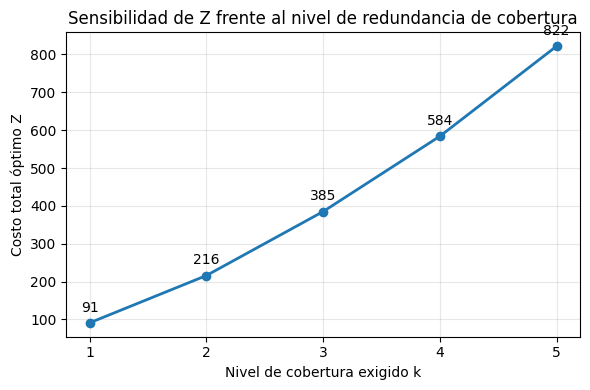

In [ ]:
#Gráfica de sensibilidad
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(df_resultados["Nivel de cobertura k"], df_resultados["z"],
         marker='o', linewidth=2)
for _, row in df_resultados.iterrows():
    plt.annotate(f"{row['z']:.0f}",
                  (row["Nivel de cobertura k"], row["z"]),
                  textcoords="offset points", xytext=(0, 8), ha='center')
plt.xticks(df_resultados["Nivel de cobertura k"])
plt.xlabel("Nivel de cobertura exigido k")
plt.ylabel("Costo total óptimo Z")
plt.title("Sensibilidad de Z frente al nivel de redundancia de cobertura")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cuarto caso: Sensibilidad a la ocupación o no disponibilidad de alguna columna

Para el siguiente análisis se añade una nueva restricción donde se usen las columnas de la solución base. A las columnas solución base se les asigna un valor de 0, para que no las tenga en cuenta el modelo. Además se añade una cota superior de 0 para cada solución base.

In [ ]:
#Asignación de 0 a las columnas de la solución base
resultados_disp = []

for j_out in solu_base:
    m_d = gp.Model('disponibilidad', env=env)

    X_d = m_d.addVars(columnas, vtype=GRB.BINARY, name='X')
    m_d.setObjective(gp.quicksum(X_d[j] * costo[j] for j in columnas), GRB.MINIMIZE)
    m_d.addConstrs((gp.quicksum(X_d[j] for j in cover_dict[i]) >= 1 for i in cover_dict),
        name='rest_covertura')

    # Restricción adicional: la columna j_out no puede usarse
    X_d[j_out].ub = 0

    m_d.optimize()

    resultados_disp.append({
        "Columna eliminada": j_out,
        "Costo original c_j": costo[j_out],
        "Z sin esta columna": m_d.ObjVal,
        "Incremento en Z": m_d.ObjVal - obj_base,
    })

df_resultados_disp = pd.DataFrame(resultados_disp).sort_values(
    "Incremento en Z", ascending= False
)
df_resultados_disp.index = [''] * len(df_resultados_disp)
df_resultados_disp

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2830402 - for non-commercial use only - registered to cc___@unal.edu.co
Optimize a model with 50 rows, 200 columns and 1211 nonzeros (Min)
Model fingerprint: 0x64e06412
Model has 200 linear objective coefficients
Variable types: 0 continuous, 200 integer (200 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 716.0000000
Presolve removed 0 rows and 126 columns
Presolve time: 0.00s
Presolved: 50 rows, 74 columns, 499 nonzeros
Found heuristic solution: objective 205.0000000
Variable types: 0 continuous, 74 integer (74 binary)

Root relaxation: objective 1.096667e+02, 40 iterations, 0.00 seconds (0.00 work 

,Columna eliminada,Costo original c_j,Z sin esta columna,Incremento en Z
,3,4.0,115.0,24.0
,129,19.0,111.0,20.0
,165,2.0,106.0,15.0
,114,5.0,103.0,12.0
,181,1.0,101.0,10.0
,70,9.0,100.0,9.0
,118,9.0,97.0,6.0
,10,14.0,96.0,5.0
,14,12.0,92.0,1.0
,17,5.0,92.0,1.0


Según la tabla al eliminar columnas como la 3 y la 129, el costo mínimo incrementa de manera considerable. Estas dos columnas se podrían tomar como las columnas críticas. También se podría decir que son las columnas más eficientes ya que cubren una gran cantidad de filas a un costo bajo, contrario a columnas como la 14, la 17 o la 61, las cuales reflejan baja sensibilidad en cuanto a la modificación de la solución óptima. Si se eliminan estas columnas, el costo total apenas incrementa en una unidad.



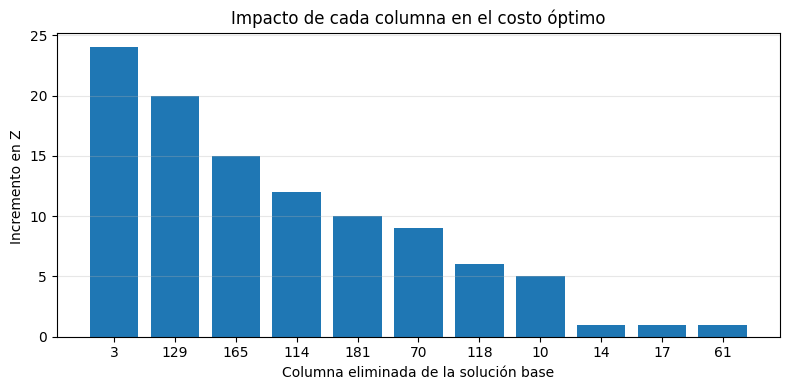

In [ ]:
#Gráfica sobre impacto en el costo mínimo
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(df_resultados_disp["Columna eliminada"].astype(str),
        df_resultados_disp["Incremento en Z"])
plt.xlabel("Columna eliminada de la solución base")
plt.ylabel("Incremento en Z ")
plt.title("Impacto de cada columna en el costo óptimo")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusión

El análisis de sensibilidad si se aterriza a un problema real como la aplicación de asignación de tripulaciones en una aereolínea (Pilotos y azafatas), es sumamente vital en el momento que se debe tomar decisiones a partir de cambios, modificaciones, imprevistos que afecten directamente en el aumento de costos. Tomar decisiones inteligentes a partir de dicho análisis puede ser la diferencia entre generar más gastos, aumentar las utilidades o permanecer estables, según las situaciones que se generen dentro del negocio o factores externos.


# Análisis de Red: [twitter-copen](https://networkrepository.com/rt-twitter-copen.php)

## Dataset y modelo utilizado

El dataset utilizado corresponde a una red de retweets y menciones generada durante una conferencia de la ONU celebrada en Copenhague (Ahmed et al., 2010). Los datos fueron obtenidos del repositorio [Network Data Repository](https://networkrepository.com/) (Rossi & Ahmed, 2015), una plataforma de acceso abierto que reúne grafos reales con herramientas de visualización interactiva integradas. La red se representa como un grafo no dirigido, donde cada nodo corresponde a un usuario de Twitter y cada arista representa una interacción, ya sea un retweet o una mención entre dos usuarios. En total, la red cuenta con 761 nodos y 1.029 aristas.

Se escogió este dataset porque presenta una estructura interesante para el análisis: es una red lo suficientemente grande para observar patrones reales de comportamiento social, pero con muy pocas conexiones relativas, lo que la convierte en un caso adecuado para estudiar propiedades de redes dispersas. Adicionalmente, al estar construida sobre interacciones reales de Twitter durante un evento de relevancia internacional, el contexto permite interpretar los resultados de manera intuitiva.

Para la exploración visual se utilizó [GraphVis](https://networkrepository.com/graphvis.php) (Rossi & Ahmed, 2015), el visualizador interactivo integrado en Network Data Repository.

## Observaciones sobre la red

Las decisiones de configuración visual adoptadas en GraphVis fueron las siguientes:

- **Nodos:** Se ajustó su tamaño y color por grado, de modo que los nodos de color rojo y tamaño reducido corresponden a usuarios con pocas conexiones; los de color azul y mayor tamaño representan los usuarios más activos. Esta configuración permite identificar los nodos de mayor influencia sin necesidad de aplicar filtros adicionales.

- **Aristas:** Se ajustó su grosor y color de acuerdo a su *betweenness*; el *betweenness* de una arista cuantifica cuántos caminos mínimos entre pares de nodos atraviesan dicha conexión, es decir, qué tan determinante es esa arista para mantener la conectividad de la red. Las aristas más gruesas y oscuras son las que actúan como puentes críticos. Se eligió este parámetro porque complementa la coloración de los nodos: mientras el grado indica qué nodos son influyentes, el betweenness indica qué conexiones son indispensables para el flujo de información.

<div style="display:flex; gap:12px; align-items:flex-start; margin:12px 0;">
  <figure style="flex:1; margin:0; text-align:center;">
    <img src="https://drive.google.com/uc?export=view&id=1t2crs-MIeM5vTtXC6RIP3_ZN2Q26ygRt"
         style="width:50%; border-radius:6px; border:1px solid #ddd;">
  </figure>
  <figure style="flex:1; margin:0; text-align:center;">
    <img src="https://drive.google.com/uc?export=view&id=1zWBjo47PYtmDcZ_MR1hFxEhhSufoH3Bg"
         style="width:50%; border-radius:6px; border:1px solid #ddd;">
  </figure>
</div>

### Red altamente dispersa

La red presenta una densidad de 0.004, lo que equivale a menos del 0.4% de todas las conexiones posibles entre los 761 usuarios. Esta característica es evidente en la visualización: predominan los nodos de tamaño reducido y color rojo, las aristas son en su mayoría delgadas y claras, y existen amplias zonas vacías en el grafo. Esto indica que la gran mayoría de los participantes interactuó de forma puntual durante el evento, sin generar una red de relaciones sostenida.

### Presencia de nodos dominantes

El grado máximo de la red es 37, mientras que el grado promedio es apenas 2.7. Esta diferencia señala que un grupo reducido de nodos concentra la mayor cantidad de interacciones. Para analizar este núcleo, se aplicó en GraphVis un filtro seleccionando únicamente los nodos con grado mayor o igual a 5, obteniéndose un subconjunto de 97 nodos, tan solo el 12.7% del total.

<div style="display:flex; gap:12px; align-items:flex-start; margin:12px 0;">
  <figure style="flex:1; margin:0; text-align:center;">
    <img src="https://drive.google.com/uc?export=view&id=12uu0xzrbhHUR0F4V4p31l-LvSZg1bfkb"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
  </figure>
  <figure style="flex:1; margin:0; text-align:center;">
    <img src="https://drive.google.com/uc?export=view&id=1t9XoRMVX8kOFxBRDeoJgvZhndYXPOojA"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
  </figure>
</div>

La primera imagen muestra la proporción de nodos excluidos del núcleo respecto a la red completa, mientras que la segunda permite observar la densidad interna de ese subconjunto. Dentro del núcleo, el nodo de mayor relevancia es el nodo 137, cuya información se detalla a continuación.

<div style="text-align:center; margin:12px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1YAgWDXrbRozbYgMb4TbMByQEHbe2bQsY"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
  </figure>
</div>

El nodo 137 presenta un grado de 35 y el *betweenness* más alto de toda la red (67.000), lo que lo convierte en el principal intermediario de la red: la mayoría de los caminos más cortos entre pares de nodos pasan por él. Su coeficiente de clustering es de apenas 0.05, lo que indica que, pese a tener muchas conexiones, sus vecinos no tienden a conectarse entre sí. Se trata de un nodo distribuidor, no de un nodo perteneciente a una comunidad cerrada. Su distancia media a los demás nodos es de 3.2, notablemente menor que el promedio global de 5.35, lo que confirma su posición central en la red.

### Comparación entre núcleo y periferia

Con el fin de contrastar cuantitativamente ambas regiones de la red, se comparan a continuación las métricas más relevantes del núcleo (grado ≥ 5), la periferia (grado ≤ 4) y la red completa:

| Métrica | Red completa | Núcleo (grado ≥ 5) | Periferia (grado ≤ 4) |
|---|:---:|:---:|:---:|
| Nodos | 761 | 97 | 664 |
| Aristas | 1029 | 207 | 229|
| Densidad | 0.004 | 0.04 | 0.001 |
| Clustering local promedio | 0.08 | 0.20 | 0.01 |
| Comunidades detectadas | 121 | 7 | 102 |
| Betweenness máximo | 67.000 | 993 | 39 |

La densidad del núcleo es diez veces mayor que la de la red completa y cuarenta veces mayor que la de la periferia, lo que confirma que los 97 nodos centrales están considerablemente más interconectados entre sí. El coeficiente de clustering refuerza esta observación: en el núcleo vale 0.20, frente a 0.01 en la periferia, indicando que dentro del núcleo los vecinos de un nodo tienden a conocerse entre sí, mientras que en la periferia esto prácticamente no ocurre.

El número de comunidades también es ilustrativo: la periferia, con 664 nodos, presenta 102 comunidades, lo que evidencia que no existe estructura interna real — se trata de pequeños grupos aislados organizados alrededor de un único intermediario. El núcleo, en cambio, con solo 97 nodos, presenta únicamente 7 comunidades, lo que habla de una mayor cohesión interna.

Los 664 nodos periféricos, al visualizarse de forma aislada, conforman una red prácticamente plana: pocas aristas, betweenness máximo de apenas 39 y casi ningún triángulo (2 en total). Sin los nodos de alto grado como intermediarios, esta región de la red no presenta capacidad de difusión propia.

<div style="text-align:center; margin:12px 0;">
  <figure style="display:inline-block; margin:0; max-width:680px; width:100%;">
    <img src="https://drive.google.com/uc?export=view&id=1gdbIcpVc9EZGhkjLAH1e8m5wpT_M5Brt"
         style="width:100%; border-radius:6px; border:1px solid #ddd;">
  </figure>
</div>

## Implicaciones sobre el comportamiento de la red

En una red de retweets, una interacción representa una decisión activa de amplificar
el mensaje de otro usuario. La estructura observada revela que esa amplificación
ocurrió de forma muy concentrada: los nodos de alto grado son los usuarios cuyos
contenidos fueron retwitteados repetidamente, mientras que la gran mayoría participó
una o dos veces sin generar eco en la red.

Esto implica que la conversación alrededor de la conferencia no fue horizontal:
el alcance de un mensaje dependió casi enteramente de si un usuario central
decidió retwittearlo. Los nodos periféricos, al no estar conectados entre sí,
no tuvieron capacidad de propagar contenido de forma independiente. En términos
de difusión, la red es eficiente pero frágil — funciona bien cuando el mensaje
nace en el núcleo, y se detiene si ese núcleo no participa.

## Análisis cuantitativo con NetworkX en el entorno Python

Para respaldar cuantitativamente las observaciones anteriores, se implementaron tres métricas básicas de análisis de grafos usando la librería [NetworkX](https://networkx.org/en/) (Hagberg et al., 2008) de Python. Las métricas seleccionadas corresponden directamente a cada una de las observaciones descritas:

- **Densidad**: Para confirmar la dispersión de la red.
- **Distribución de grado:** Para evidenciar la existencia de nodos centrales.
- **Centralidad de grado:** Para identificar los nodos más influyentes de la red.

In [ ]:
!pip install networkx matplotlib --quiet

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import urllib.request

In [ ]:
# Descarga desde Google Drive
FILE_ID = "1jXnOEvfTrN_eAyUbO_Pr8kOkHdGdxdpc"   # rt-twitter-copen.mtx
url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"
urllib.request.urlretrieve(url, "rt-twitter-copen.mtx")
print("Archivo descargado correctamente.")

# Carga del grafo
G = nx.Graph()

with open("rt-twitter-copen.mtx", "r") as f:
    for line in f:
        if line.startswith("%"):       # ignorar comentarios del encabezado
            continue
        partes = line.strip().split()
        if len(partes) == 2:           # ignorar la línea de dimensiones
            try:
                u, v = int(partes[0]), int(partes[1])
                if u != v:             # ignorar autoconexiones
                    G.add_edge(u, v)
            except ValueError:
                continue

print(f"Grafo cargado: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")

Archivo descargado correctamente.
Grafo cargado: 761 nodos, 1029 aristas


### Densidad

In [ ]:
densidad = nx.density(G)
print(f"Densidad de la red: {densidad:.6f}")
print(f"Esto equivale al {densidad*100:.3f}% de todas las conexiones posibles.")

Densidad de la red: 0.003558
Esto equivale al 0.356% de todas las conexiones posibles.


La densidad obtenida de 0.003558 confirma cuantitativamente lo observado en GraphVis: existe menos del 0.4% de todas las conexiones posibles entre los 761 usuarios. Para contextualizar, una red completamente conectada tendría densidad 1.0, y una red aleatoria típica de este tamaño rondaría valores cercanos a 0.05. El valor obtenido es, por tanto, considerablemente bajo incluso para una red social como Twitter.

### Distribución de grado

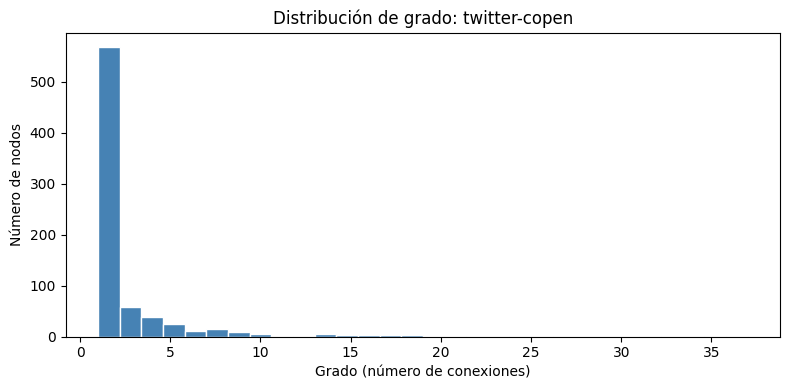

Grado promedio: 2.70
Grado máximo:   37
Nodos con grado 1: 413 (54.3%)


In [ ]:
grados = [grado for _, grado in G.degree()]

plt.figure(figsize=(8, 4))
plt.hist(grados, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Grado (número de conexiones)")
plt.ylabel("Número de nodos")
plt.title("Distribución de grado: twitter-copen")
plt.tight_layout()
plt.show()

print(f"Grado promedio: {sum(grados)/len(grados):.2f}")
print(f"Grado máximo:   {max(grados)}")
print(f"Nodos con grado 1: {grados.count(1)} ({grados.count(1)/len(grados)*100:.1f}%)")

El histograma evidencia una distribución fuertemente asimétrica: más de la mitad
de los nodos tienen grado 1, mientras que el grado máximo alcanza 37 (y solo son dos nodos por lo cual no se ve en la gráfica).
Esta forma es característica de redes sociales reales, donde unos pocos usuarios
concentran la mayor parte de las interacciones. El grado promedio de 2.7
resulta poco representativo de la red en su conjunto, dado que está sesgado
por los nodos de alto grado; la mayoría de los usuarios se sitúa muy por debajo de ese valor.

### Centralidad de grado

In [ ]:
centralidad = nx.degree_centrality(G)

# Top 5 nodos más centrales
top5 = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodos por centralidad de grado:\n")
for nodo, valor in top5:
    grado = G.degree(nodo)
    print(f"  Nodo {nodo:>4} — centralidad: {valor:.4f}  |  grado: {grado}")

Top 5 nodos por centralidad de grado:

  Nodo  137 — centralidad: 0.0487  |  grado: 37
  Nodo  158 — centralidad: 0.0461  |  grado: 35
  Nodo  693 — centralidad: 0.0408  |  grado: 31
  Nodo  358 — centralidad: 0.0342  |  grado: 26
  Nodo  397 — centralidad: 0.0329  |  grado: 25


La centralidad de grado normaliza el grado de cada nodo respecto al máximo
posible (n−1 conexiones). El nodo con mayor valor encabeza el ranking como
el usuario que interactuó con la mayor proporción de la red, y el resultado es consistente con el *betweenness* máximo observado en GraphVis (el nodo 137 es el de mayor grado (37) y le sigue otro nodo de grado 35). Los cinco nodos
del ranking concentran conexiones muy por encima del promedio (2.7),
lo que confirma cuantitativamente la presencia del núcleo identificado
visualmente al aplicar el filtro de grado ≥ 5.

## Conclusión

El análisis de la red [twitter-copen](https://networkrepository.com/rt-twitter-copen.php) (Ahmed et al., 2010) permitió identificar una estructura
típica de redes sociales de eventos: dispersa a nivel global, pero con un
núcleo reducido de usuarios que concentra la mayor parte de las interacciones.
Las métricas calculadas y la exploración visual en GraphVis coinciden en señalar
que la dinámica de retweets durante la conferencia dependió de un grupo pequeño
de nodos centrales, sin los cuales la propagación de contenido habría sido
prácticamente nula.



---



# Referencias

Ahmed, N. K., Berchmans, F., Neville, J., & Kompella, R. (2010). Time-based sampling of social network activity graphs. *SIGKDD MLG*, 1–9.

Augerat, P. (1995). *Set A — VRP-REP: The vehicle routing problem repository*. VRP-REP. http://vrp-rep.org/datasets/item/2014-0000.html

Caprara, A., Fischetti, M., & Toth, P. (2000). Algorithms for the set covering problem. *Annals of Operations Research*, 98(1), 353–390.

Ibrahim, A., Ishaya, J., Lo, N., & Abdulaziz, R. (2020). Capacitated vehicle routing problem with column generation and reinforcement learning techniques. *Open Journal of Discrete Applied Mathematics*, 3(1), 41–54. https://doi.org/10.30538/psrp-odam2020.0029

Percy Guzman, H. A. (2026). *MODEL_07_SetCovering_50x200* (Archivo de instancia matemática .lp) [Material de clase]. Departamento de Ingeniería, Universidad Nacional.

Rossi, R. A., & Ahmed, N. K. (2015). *The network data repository with interactive graph analytics and visualization*. AAAI. https://networkrepository.com

## Herramientas de software

Gurobi Optimization, LLC. (2025). *Gurobi optimizer reference manual*. https://www.gurobi.com

Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. In G. Varoquaux, T. Vaught, & J. Millman (Eds.), *Proceedings of the 7th Python in Science Conference* (SciPy 2008) (pp. 11–15).

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., … Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 51–56). https://doi.org/10.25080/Majora-92bf1922-00a

Python Software Foundation. (2024). *Python language reference*, version 3 [Software]. https://www.python.org

### Herramientas de inteligencia artificial

Anthropic. (2025). *Claude* (Versión 3.5 Sonnet) [Large language model]. https://claude.ai

Google. (2026). *Gemini* [Large language model]. https://gemini.google.com

# Anexos

- **Bitácora de uso de IA:** Documento que contiene los prompts utilizados para el uso de inteligencia artificial como herramienta de ayuda. Disponible en:
  - Google Docs: https://docs.google.com/document/d/1tDJFXFBcSyKAj4KMBiPJgILvwxePnoOLBX8JHWUcdDU/edit?usp=sharing
  - PDF: https://drive.google.com/file/d/1RKuSuUEVmayZOhkLGmJxAzxGowcJx4aL/view?usp=sharing

- **Carpeta compartida de Google Drive:** Carpeta de acceso público que contiene los archivos utilizados en el entorno Python del repositorio (de allí provienen los IDs empleados para cargar la información y procesarla). Disponible en https://drive.google.com/drive/folders/1yDjcxgzCeP9lKNSV6dUhJNc86xzd9N1f?usp=sharing